# Sheet G03 - Mesh Navigation and Subdivision
*Robin Tim Landsgesell, Jonas Marcic, Julian Stamm*
## Assignment 3) Subdivision Curves *(2 + 1Pts)*
Let P=(0, 0), (1, 0.5), (1.4, 1), (0.8, 1.2), (0.3, 0.8) be a control polygon starting at (0, 0) and
ending at (0.3, 0.8). Subdivide this polygon using

In [30]:
import matplotlib.pyplot as plt
import numpy as np

CP = np.array([(0, 0), (1, 0.5), (1.4, 1), (0.8, 1.2), (0.3, 0.8)])

def plot_poly(P):
  poly = np.vstack((P, P[0]))
  plt.plot(poly[:, 0], poly[:, 1])

a) Corner-cutting with weights (3/4, 1/4) and (1/4, 3/4).

Subdivison at i=1:
[[0.25  0.125]
 [0.5   0.25 ]
 [0.75  0.375]
 [1.1   0.625]
 [1.2   0.75 ]
 [1.3   0.875]
 [1.25  1.05 ]
 [1.1   1.1  ]
 [0.95  1.15 ]
 [0.675 1.1  ]
 [0.55  1.   ]
 [0.425 0.9  ]
 [0.225 0.6  ]
 [0.15  0.4  ]
 [0.075 0.2  ]]


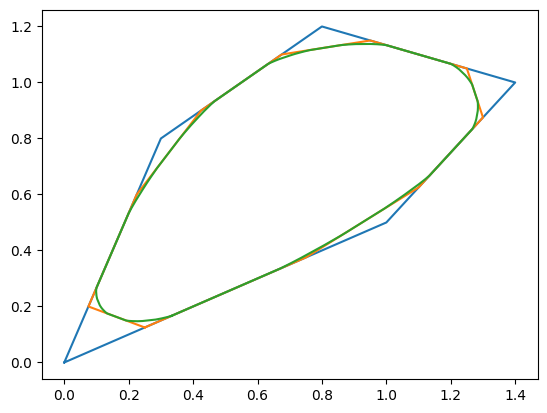

In [31]:
P = CP.copy()

def corner_cutting(P, w):
  P_new = []
  for i in range(len(P)):
    a = P[i]
    b = P[(i + 1) % len(P)]
    P_new.append((1-w) * a + w * b)
    P_new.append(0.5 * (a + b))
    P_new.append(w * a + (1-w) * b)
  return np.array(P_new)

plot_poly(P)
for i in range(5):
  P = corner_cutting(P, 0.25)
  if i == 0:
    plot_poly(P)
    print(f"Subdivison at i=1:\n{P}")
plot_poly(P)
plt.show()

b) the odd rule (0.5, 0.5) and even rule (1/8, 6/8, 1/8).

Bonus: Implement both variants of the subdivision and iterate them until convergence.

Subdivison at i=1:
[[0.5    0.25  ]
 [0.925  0.5   ]
 [1.2    0.75  ]
 [1.275  0.9625]
 [1.1    1.1   ]
 [0.8125 1.125 ]
 [0.55   1.    ]
 [0.325  0.75  ]
 [0.15   0.4   ]
 [0.1625 0.1625]]


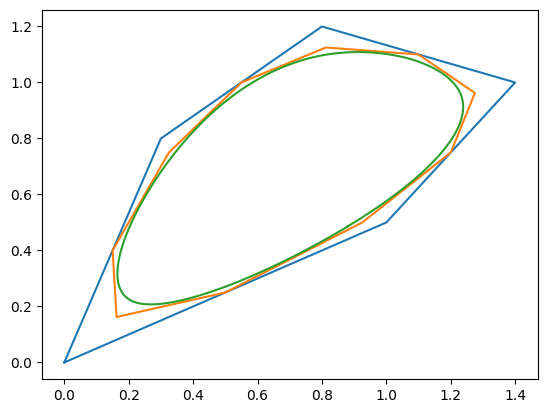

In [35]:
P = CP.copy()

def even_odd(P):
  P_new = []
  for i in range(len(P)):
    a = P[i]
    b = P[(i + 1) % len(P)]
    c = P[(i + 2) % len(P)]
    P_new.append(0.5 * a + 0.5 * b)
    P_new.append((a + 6 * b + c) / 8)
  return np.array(P_new)

plot_poly(P)
for i in range(5):
  P = even_odd(P)
  if i == 0:
    plot_poly(P)
    print(f"Subdivison at i=1:\n{P}")
plot_poly(P)
plt.show()

# Assignment 4) Subdivision Surfaces *(4Pts)*
*a) Describe how the sqrt3-subdivision algorithm works. Go through every step and describe how you can subdivide a mesh using this approach.*

1) For each triangle insert the midpoint.
2) For each quadrangle spanned between the midpoints of two neighboring triangles flip the original edge. The resulting triangulation has twice as many triangles as the original mesh.
3) For a complete subdivision algorithm a geometric rule has to be applied after that which moves the generated points to new positions obtained by linear combination of the original points.

*b) What problems can you find using a subdivision approach? Are there solutions to these problems?*

Extraordinary vertices (with non-regular valence) can produce irregularities. The Loop and Modified Butterfly schemes handle these more gracefully.
Another alternative is fixing the base topology.

*c) What are the main differences between loop/catmull-clark/sqrt3-subdivision approaches?*

Sqrt3 is a topological rule the other ones are geometric rules.
Catmull-Clark and Loop both achieve C2 continuity on non-extraordinary points. However Catmull-Clark operates on quadrangles and Loop on triangles
